In [271]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False

In [272]:
import torch
!gdown --id 16MIleqoIr1vYxlGk4GKnGmrsCPuWkkpT
!unzip -qq ECG5000.zip
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=16MIleqoIr1vYxlGk4GKnGmrsCPuWkkpT
To: /content/ECG5000.zip
100% 10.6M/10.6M [00:00<00:00, 257MB/s]
replace ECG5000.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ECG5000_TEST.arff? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ECG5000_TEST.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ECG5000_TRAIN.arff? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ECG5000_TRAIN.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ECG5000_TEST.ts? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ECG5000_TRAIN.ts? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [273]:
!pip install liac-arff
import arff as a2p

with open('ECG5000_TRAIN.arff') as f:
    train = a2p.load(f)

with open('ECG5000_TEST.arff') as f:
    test = a2p.load(f)

## We concatenate the training and testing datsaet

In [274]:
import pandas as pd
df_train = pd.DataFrame(train['data'])
df_test = pd.DataFrame(test['data'])
df = pd.concat([df_train, df_test])

df = df.sample(frac=1.0).reset_index(drop=True)
print(df.shape)

(5000, 141)


In [275]:
df

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.721115,-2.399256,-3.185413,-4.072469,-4.152224,-3.558622,-2.349179,-1.578811,-1.413717,-0.744644,...,0.888936,0.150838,-0.738586,-1.327099,-1.784050,-1.482645,-0.723111,-0.296797,-1.248188,1
1,-1.052368,-1.930834,-2.616737,-3.077624,-3.581610,-3.606576,-3.265797,-2.406501,-1.212914,-1.039625,...,1.243870,0.694567,-0.243453,-1.297368,-2.157524,-2.444063,-2.237213,-1.375612,-1.394051,1
2,-0.756247,-1.828567,-2.240693,-2.620162,-2.748183,-2.869855,-2.739284,-2.333614,-1.797843,-1.312772,...,-1.616584,-2.242546,-2.935456,-3.559296,-3.732286,-3.215271,-2.013148,-0.953563,0.194009,2
3,-1.739532,-3.248969,-3.657210,-4.268318,-3.758126,-3.235361,-2.267531,-1.588325,-1.444583,-1.162514,...,1.656026,1.459578,1.092420,0.638151,0.154056,-0.137005,0.007240,0.334026,-0.546224,1
4,-0.135370,-1.355503,-1.895670,-2.362370,-2.490547,-2.539750,-2.501838,-2.314082,-2.046386,-1.545088,...,-2.110884,-2.515010,-3.140973,-3.654510,-3.775654,-3.135748,-1.963182,-1.243051,0.198764,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.614441,-1.460638,-3.643040,-4.611715,-4.109091,-3.331020,-2.270393,-1.774899,-1.491241,-0.723065,...,1.187527,1.385507,1.762009,1.872403,1.522077,1.162915,1.123072,1.328743,-0.149059,1
4996,0.752034,-0.094338,-0.834128,-1.414400,-1.775097,-2.245504,-2.440991,-2.397037,-2.187195,-1.713660,...,-3.196423,-3.730875,-3.993996,-3.522622,-2.531339,-1.379661,-0.387222,-0.187528,0.581293,2
4997,1.423231,1.673123,0.351329,-1.463255,-2.927487,-4.007862,-3.711384,-2.651975,-1.913533,-1.793887,...,0.186891,0.819867,0.898301,1.037710,1.318917,1.633258,1.492708,0.925830,1.610096,1
4998,3.013619,1.485195,-1.196120,-2.819344,-4.096166,-4.606579,-3.237565,-1.452775,-0.846476,-0.341013,...,0.184004,1.577016,1.110480,1.324434,1.086480,0.543767,-0.988811,-1.933640,-1.461328,1


In [276]:
df.columns

RangeIndex(start=0, stop=141, step=1)

In [277]:
df = df.add_prefix('c') ## Just for better clarification of column

In [278]:
df.columns

Index(['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9',
       ...
       'c131', 'c132', 'c133', 'c134', 'c135', 'c136', 'c137', 'c138', 'c139',
       'c140'],
      dtype='object', length=141)

In [279]:
df['c140'].value_counts()

,count
c140,
1,2919
2,1767
4,194
3,96
5,24


In [280]:
df['c140'].unique()

array(['1', '2', '3', '4', '5'], dtype=object)

In [281]:
df.describe()

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c130,c131,c132,c133,c134,c135,c136,c137,c138,c139
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.262476,-1.649511,-2.492211,-3.119443,-3.167438,-2.866308,-2.273126,-1.798127,-1.410124,-0.936082,...,0.146319,0.070973,-0.062914,-0.276206,-0.507667,-0.761043,-0.834741,-0.642263,-0.487242,-0.706008
std,1.152369,1.445493,1.386409,1.302802,1.104382,0.906133,0.731627,0.623100,0.637149,0.657945,...,1.171299,1.404842,1.646585,1.895134,2.059758,2.086218,2.056220,1.859296,1.830987,1.414465
min,-6.729499,-7.090374,-5.132459,-5.363241,-5.375715,-5.330194,-4.782240,-4.311288,-4.071361,-4.142476,...,-3.971715,-4.167040,-4.557576,-4.530488,-4.563270,-5.150100,-4.880460,-5.496107,-5.880890,-6.092227
25%,-1.004511,-2.701576,-3.668096,-4.227247,-4.007470,-3.480479,-2.779941,-2.165851,-1.774124,-1.362068,...,-0.655753,-1.089300,-1.588885,-2.147449,-2.731550,-3.030509,-2.868331,-2.153513,-1.657771,-1.596692
50%,-0.297541,-1.661892,-2.585677,-3.387934,-3.468718,-2.947061,-2.285578,-1.750157,-1.422570,-0.910487,...,0.473642,0.658318,0.717808,0.604747,0.334857,-0.030767,-0.195151,-0.194423,-0.160262,-0.565588
75%,0.500061,-0.677290,-1.513964,-2.235369,-2.530967,-2.398813,-1.823494,-1.484923,-1.063708,-0.476660,...,1.062134,1.169420,1.238687,1.264471,1.234433,1.034584,0.945237,0.951681,1.002692,0.272012
max,4.966414,3.479689,2.660597,1.899798,2.147015,1.614375,1.868728,1.804251,1.683730,1.898627,...,2.960969,3.007606,2.854680,2.912394,2.937685,3.351437,3.432519,3.579448,4.425976,7.402103


### Split the Dataset using SCK

In [282]:
train_data, test_data, train_labels, test_labels = train_test_split(df.values, df.values[:,0:1], test_size=0.2, random_state=111)

Scaling is like "normalizing" the volume of different speakers so they can all be heard clearly. In machine learning
Scaling brings everything into a range like 0 to 1

Min-Max scaler is to squeeze all your data points into a specific range, usually between 0 and 1. This is crucial for ECG data because neural networks (especially Autoencoders) converge much faster when the input values are on the same scale.

In [283]:
scaler = MinMaxScaler() # Scaling train_data alone
data_scaled = scaler.fit(train_data)

Upon fit the scaler on dataset it return two numbers: the lowest value and highest value in dataset

my scalar fit will learn the parameters using the train data... and I am going to use the learn parameter to transform the test data set, the transfom is shown in nexet cell

In [284]:
train_data_scaled = data_scaled.transform(train_data)
test_data_scaled = data_scaled.transform(test_data)

In [285]:
train_data_scaled

array([[0.62069648, 0.551573  , 0.319188  , ..., 0.64541405, 0.42709264,
        0.        ],
       [0.47594865, 0.47863363, 0.33782437, ..., 0.35252454, 0.3691703 ,
        0.25      ],
       [0.49088489, 0.50882505, 0.34387148, ..., 0.56706749, 0.46545108,
        0.25      ],
       ...,
       [0.65095197, 0.57466972, 0.23295379, ..., 0.69759136, 0.42401178,
        0.        ],
       [0.47064829, 0.31640292, 0.16727463, ..., 0.69991652, 0.3637524 ,
        0.        ],
       [0.48559921, 0.5223097 , 0.59893851, ..., 0.45195802, 0.41069497,
        1.        ]])

In [286]:
print(train_labels[:10])

[[0.53011325]
 [-1.1628447]
 [-0.9881518]
 [0.44034205]
 [-1.7205153]
 [-1.7792213]
 [-1.392636]
 [3.0400547]
 [-0.47857737]
 [-0.27999563]]


We will split the training data into normal and anamoly data, what we do its ignoring last column (which are the
label for results of heartbeat: 1->normal and 2,3,4,
5->anamoly)

In [287]:
train_df = pd.DataFrame(train_data_scaled).add_prefix('c')
test_df = pd.DataFrame(test_data_scaled).add_prefix('c')

In [288]:
train_df

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c131,c132,c133,c134,c135,c136,c137,c138,c139,c140
0,0.620696,0.551573,0.319188,0.208367,0.156854,0.256042,0.340512,0.411279,0.411060,0.537104,...,0.760829,0.826706,0.828018,0.781254,0.716807,0.659869,0.676273,0.645414,0.427093,0.00
1,0.475949,0.478634,0.337824,0.325639,0.316327,0.335083,0.341105,0.372610,0.454230,0.509299,...,0.460022,0.442497,0.368939,0.220777,0.190906,0.100050,0.270621,0.352525,0.369170,0.25
2,0.490885,0.508825,0.343871,0.346291,0.341316,0.404899,0.422870,0.473330,0.515964,0.520100,...,0.263913,0.251954,0.147970,0.105654,0.232383,0.334381,0.519328,0.567067,0.465451,0.25
3,0.613021,0.686502,0.447651,0.298664,0.165356,0.065498,0.116024,0.318686,0.423288,0.483758,...,0.661633,0.845285,0.876831,0.848213,0.831987,0.799919,0.746303,0.586881,0.485761,0.00
4,0.428268,0.287533,0.124394,0.150668,0.183746,0.303319,0.447804,0.498327,0.520947,0.608158,...,0.735854,0.811910,0.832491,0.797334,0.726986,0.667485,0.717005,0.681201,0.361649,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.485689,0.450241,0.308327,0.308072,0.302996,0.331345,0.321706,0.358159,0.429144,0.501544,...,0.411928,0.385357,0.293843,0.207894,0.179564,0.140006,0.329093,0.402928,0.428550,0.25
3996,0.484486,0.425595,0.250070,0.311122,0.337861,0.404055,0.456017,0.509375,0.550585,0.562997,...,0.543028,0.555415,0.473237,0.411252,0.363697,0.215753,0.146591,0.173296,0.218518,0.25
3997,0.650952,0.574670,0.232954,0.122388,0.136986,0.260815,0.354859,0.413685,0.448407,0.564938,...,0.725692,0.792444,0.839659,0.840562,0.783723,0.718408,0.724836,0.697591,0.424012,0.00
3998,0.470648,0.316403,0.167275,0.149368,0.230829,0.407042,0.437438,0.430347,0.551054,0.623028,...,0.770217,0.795426,0.768371,0.714151,0.671824,0.652958,0.714250,0.699917,0.363752,0.00


In [289]:
normal_train_data= train_df.query('c140 == 0').values[:,:-1]

In [290]:
anamoly_train_data = train_df.query('c140 > 0').values[:,:-1]

Doing same for Test data as well

In [291]:
normal_test_data= test_df.query('c140 == 0').values[:,:-1]

In [292]:
anamoly_test_data = test_df.query('c140 > 0').values[:,:-1]

In [293]:
print(normal_train_data.shape)

(2343, 140)


In [294]:
print(anamoly_train_data.shape)

(1657, 140)


In [295]:
print(normal_test_data.shape)

(576, 140)


In [296]:
print(anamoly_test_data.shape)

(424, 140)


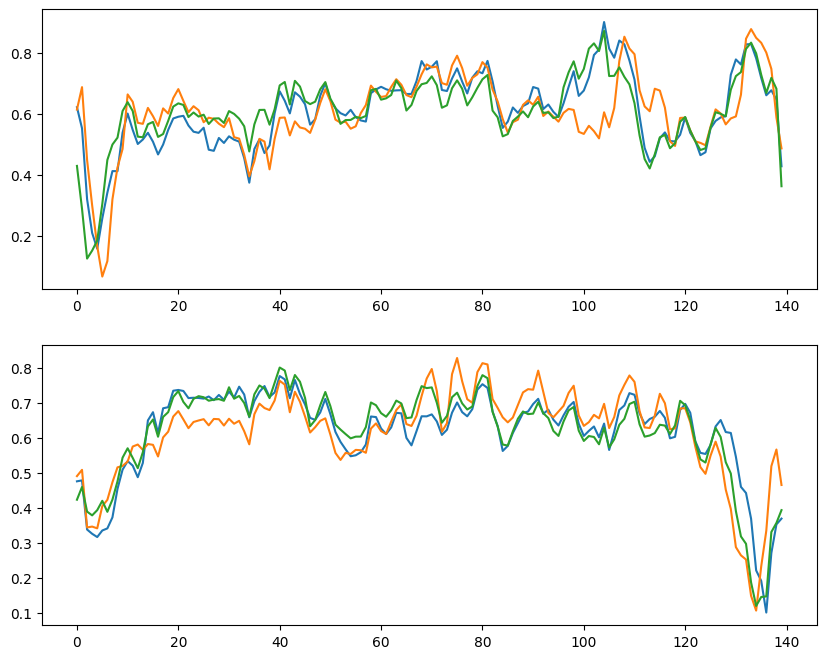

In [297]:
plt.subplot(2,1,1)
plt.plot(normal_train_data[0])
plt.plot(normal_train_data[1])
plt.plot(normal_train_data[2])
plt.subplot(2,1,2)
plt.plot(anamoly_train_data[0])
plt.plot(anamoly_train_data[1])
plt.plot(anamoly_train_data[2])

## Implementing Auto-Encoder

In [298]:
model = tf.keras.Sequential()
# Encoders
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))
# Bottleneck layer
model.add(tf.keras.layers.Dense(8, activation='relu'))
#Decoder
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(140, activation='sigmoid'))



Reconstruction of normal data by taking normal data as input

When this learned reconstruction happen on anamolous data, there is error and comparing that error with threshold value of ours, we can determine abnormalitites

In [299]:
# Another way of constructing Auto encoder where we can use layers themselves for different functionalities
class AutoEncoder(Model):
  def __init__(self):
    super(AutoEncoder,self).__init__()
    self.encoder = tf.keras.Sequential([ # creating Encoder
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu")])

    self.decoder = tf.keras.Sequential([ # creating decoder
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(140, activation="sigmoid")])

  def call(self,x):
    encoded = self.encoder(x) # passing the input data
    decoded = self.decoder(encoded) # getting decoded value
    return decoded


Validation loss is a metric used in machine learning to measure how well your model performs on data it has never seen before during training. After training(epoch run) we calculate this validation loss

In [300]:
model = AutoEncoder()
# we aim to stop our model unless validation loss does not run for more than two epochs
# mode is set min for calculating validation loss
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')
model.compile(optimizer='adam', loss='mae')
#Adaptive Moment Estimation. It is essentially a "smart" version of Gradient Descent that adjusts how much it changes the model's weights based on how the training is going.
# Loss function is Mean Absolute Error which is common for Autoencoders

Fitting the model on Normal Train Dataset, for validation we pass entire datset(normal+anamoulous)

Because on normal data the reconstruction is perfect and thus on validation has low mae(Mean Absolute Error)

But when anamoly+normal is passed for validation the model tries to fit but won't be able to do it perfectly and thus mae goes higher

Now when we set threshold we'll be able to classify things as normal or anamoly

In [301]:
history = model.fit(normal_train_data,normal_train_data,
                    epochs = 50,
                    batch_size=128,
                    validation_data=(train_data_scaled[:,:-1], train_data_scaled[:,:-1]),
                    shuffle=True, # makes model as simple feedforward neural network instead of lstm
                    callbacks=[early_stopping])

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.1251 - val_loss: 0.1105
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0763 - val_loss: 0.0799
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0507 - val_loss: 0.0739
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0457 - val_loss: 0.0723
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0451 - val_loss: 0.0729
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0449 - val_loss: 0.0721
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0447 - val_loss: 0.0717
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0443 - val_loss: 0.0711
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0434 - val_loss: 0.0700
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0416 - val_loss: 0.0679
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0386 - val_loss: 0.0646
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.

The difference in loss and validation doesn't mean we have underfitting model instead that supports our point of sending validation dataset as (normal+anamolous)

Model is trained and we can get our encoded data and decoded data separately

In [302]:
# 140 unit input to 8 unit compressed unit
encoder_out = model.encoder(normal_test_data).numpy()
# Decoder constructs back bottlenecked unit
decoder_out = model.decoder(encoder_out).numpy()

In [303]:
encoder_out.shape

(576, 8)

In [304]:
decoder_out.shape

(576, 140)

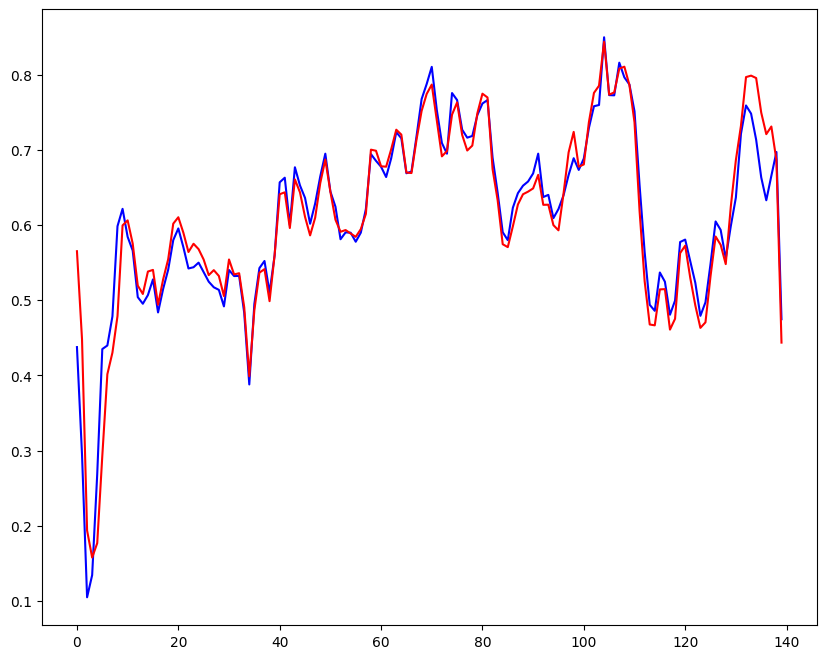

In [305]:
plt.plot(normal_test_data[0],'b')
plt.plot(decoder_out[0],'r')

Model works well because we our model was trained on normal data but let's do same with anamolous data

In [306]:
encoder_out_a = model.encoder(anamoly_test_data).numpy()
decoder_out_a = model.decoder(encoder_out_a).numpy()

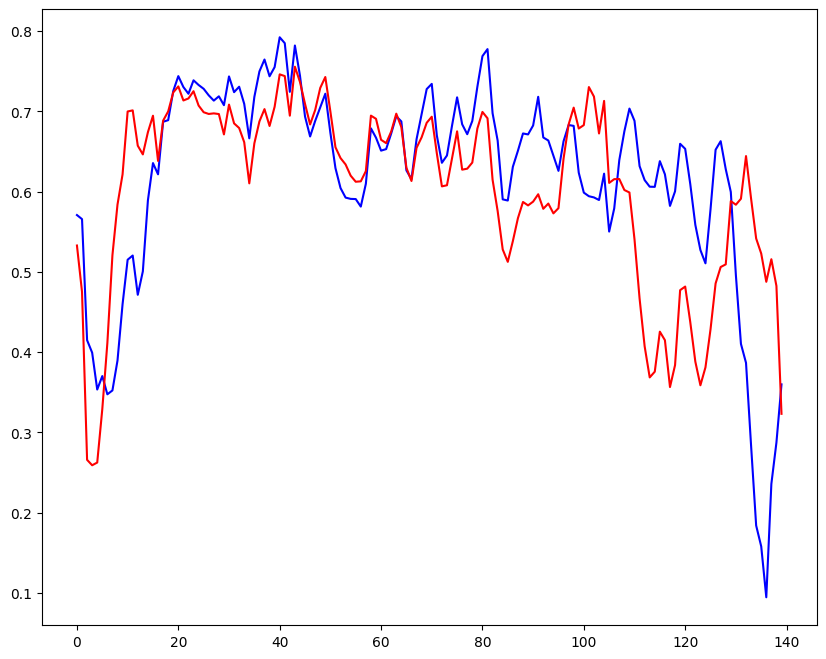

In [307]:
plt.plot(anamoly_test_data[0],'b')
plt.plot(decoder_out_a[0],'r')

Reconstruction Error is pretty high as we can visually introspect for anamolous data

Now our model is mature to reconstruct the data if normal with very less reconstruction error

While also recognizing Anamoous Data with higher reconstruction error

We will define loss threshold for our model

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


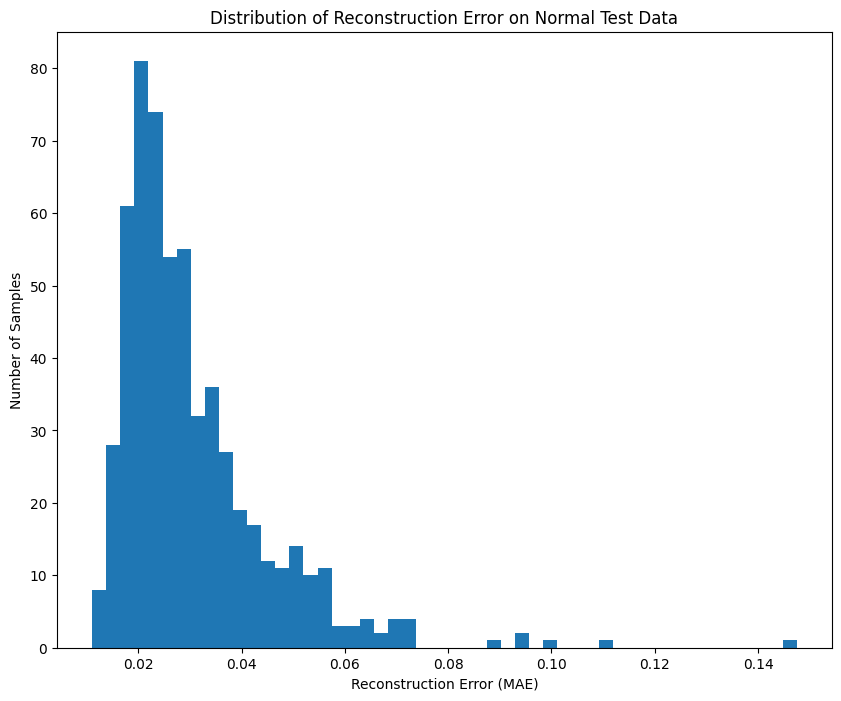

In [308]:
reconstructions = model.predict(normal_test_data)
# this will give me an reconstructed ouput for input as normal test data which should be very accurate as model is trained on normal train data
test_loss = tf.keras.losses.mae(reconstructions, normal_test_data)
# we get reconstruction loss btw normal test data and reconstructed data
plt.hist(test_loss, bins=50)
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Error on Normal Test Data")

plt.show()

The distribution of error for was very small for most hearbeats but increases for a few, this proves that we have high reconstruction for normal datset

Now from this plot we can take our threshold value for defining another datasets as abnormal or normal

In [309]:
np.mean(test_loss)

np.float64(0.030522875753323686)

In [310]:
np.std(test_loss)

np.float64(0.014630005974555741)

In [311]:
threshold = np.mean(test_loss) + 2*np.std(test_loss)
# we have decided above formula according to our requirements

In [312]:
threshold

np.float64(0.05978288770243517)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


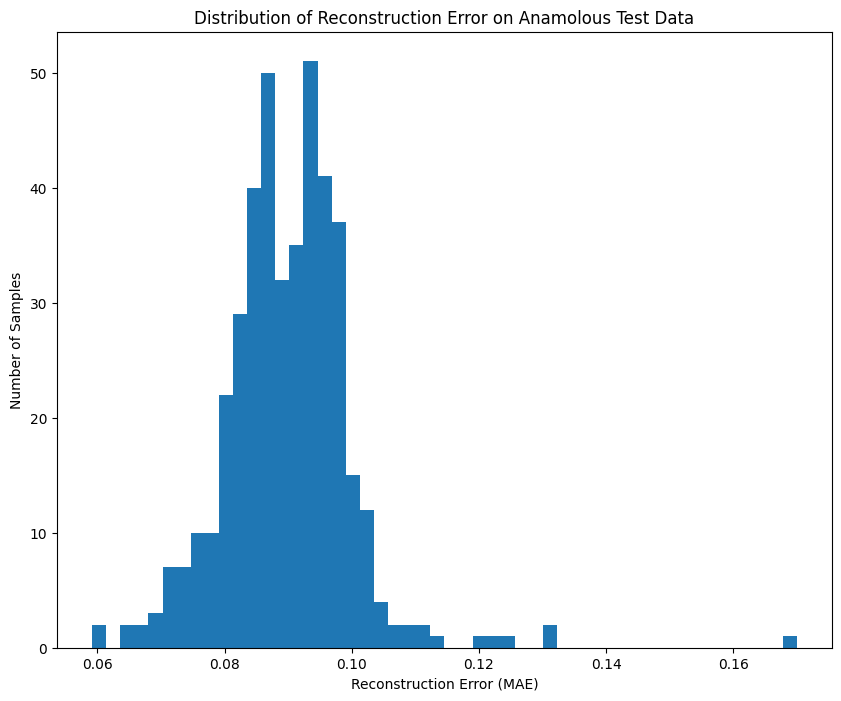

In [313]:
reconstructions = model.predict(anamoly_test_data)
test_loss_a = tf.keras.losses.mae(reconstructions, anamoly_test_data)

plt.hist(test_loss_a, bins=50)
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Error on Anamolous Test Data")

plt.show()

Most observations are above our figured threshold thus our findings are good

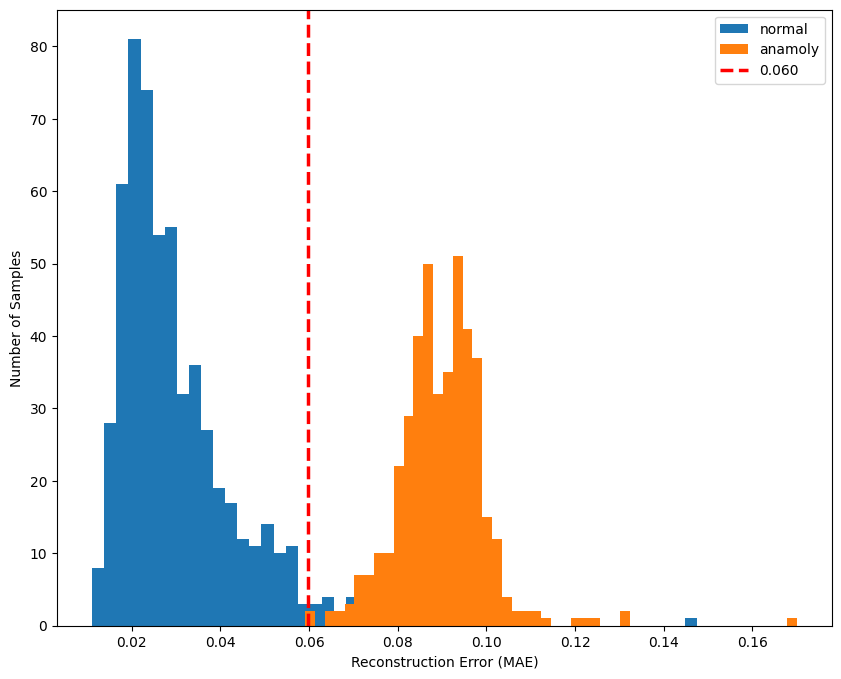

In [314]:
plt.hist(test_loss, bins=50, label='normal')
plt.hist(test_loss_a, bins=50, label='anamoly')
plt.axvline(threshold, color='r', linewidth=2.5, linestyle='dashed', label='{:0.3f}'.format(threshold))
plt.legend(loc='upper right')
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Number of Samples")
plt.show()



Few anamolies below threshold are false positives

In [315]:
np.mean(test_loss_a)

np.float64(0.0898899100914347)

In [316]:
np.std(test_loss_a)

np.float64(0.01008244691417947)

In [317]:
tf.math.less(test_loss, threshold)

<tf.Tensor: shape=(576,), dtype=bool, numpy=
array([ True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  Tr

In [318]:
# this gives how many values in normal_test_data are less than threshold
preds = tf.math.less(test_loss, threshold)

In [319]:
preds.shape
# total values predicted in normal_test_data

TensorShape([576])

In [320]:
tf.math.count_nonzero(preds)
# how many predicted correctly

<tf.Tensor: shape=(), dtype=int64, numpy=553>

In [325]:
# this gives how many values in anamolous_test_data are greater than threshold
preds_a = tf.math.greater(test_loss_a, threshold)

In [322]:
preds_a.shape


TensorShape([424])

5

In [326]:
tf.math.count_nonzero(preds_a)
# values predicted right

<tf.Tensor: shape=(), dtype=int64, numpy=423>

In [324]:
preds = tf.math.less(test_loss, threshold)
normal_correct = tf.math.count_nonzero(preds).numpy()
print(f"Normal correctly identified: {normal_correct} / {len(test_loss)}")

preds_a = tf.math.greater(test_loss_a, threshold)
anomaly_correct = tf.math.count_nonzero(preds_a).numpy()
print(f"Anomalies correctly identified: {anomaly_correct} / {len(test_loss_a)}")

# net accuracy
total_correct = normal_correct + anomaly_correct
total_samples = len(test_loss) + len(test_loss_a)
print(f"Total Accuracy: {total_correct / total_samples:.2%}")

Normal correctly identified: 553 / 576
Anomalies correctly identified: 423 / 424
Total Accuracy: 97.60%


Successful Model